# CNN Emotion Classification - Experiment

## 1. Dataset Exploration

### Sample Images

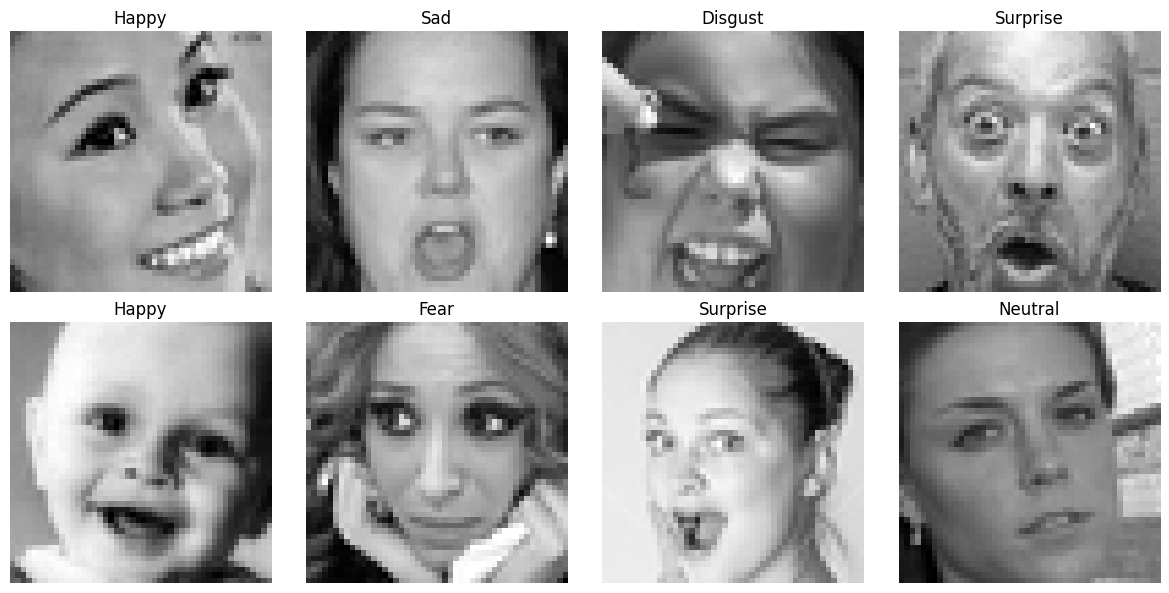

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import random

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")

indices = random.sample(range(len(val_dataset)), 8)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(FERDataset.class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Experiments

### Run Experiment

Run the current experiment from the project root:

```bash
python src/main.py --experiment xxx --model xxx --description "xxx"
```

### Experiment Summary

In [42]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from experiments import experiment_summary_records, list_experiments

available_experiments = list_experiments(ROOT)
experiment_summary = pd.DataFrame(
    experiment_summary_records(ROOT),
    columns=[
        "Experiment",
        "Architecture",
        "Main Change",
        "Best Val Accuracy",
        "Epochs",
    ],
)

# Keep missing values as None/NaN in the DataFrame; replace them only when rendered.
experiment_summary_display = experiment_summary.style.format(na_rep="—")

print(f"Available experiments: {available_experiments}")
display(experiment_summary_display)

Available experiments: ['simple_baseline', 'vgg_baseline', 'vgg_v1_batchnorm', 'vgg_v2_4block', 'vgg_v3_augmentation', 'vgg_v4_extended_training']


,Experiment,Architecture,Main Change,Best Val Accuracy,Epochs
0,simple_baseline,SimpleCNN,Shallow 2-convolution CNN baseline.,0.505155,10
1,vgg_baseline,VGGStyleCNN,Deeper 6-convolution VGG-style baseline testing increased depth alone.,0.584564,10
2,vgg_v1_batchnorm,VGGStyleCNNV1,VGG baseline with BatchNorm after every convolution,0.602953,10
3,vgg_v2_4block,VGGStyleCNNV2,VGG baseline with a 4th convolutional block.,0.624687,10
4,vgg_v3_augmentation,VGGStyleCNNV2,V2 with training-only data augmentation,0.558930,10
5,vgg_v4_extended_training,VGGStyleCNNV2,V3 augmentation with extended training and early stopping,0.675118,30


### Training Comparison

Set `EXPERIMENT` to a run listed above. Its saved config automatically selects the correct architecture. New runs require both a unique experiment ID and a model architecture.

In [43]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from experiments import load_config
from main import get_results_dir, load_history

# Select one experiment for detailed analysis.
EXPERIMENT = "vgg_v4_extended_training"

experiment_config = load_config(EXPERIMENT, ROOT)
MODEL_NAME = experiment_config["model"]  # Architecture key used by Grad-CAM.
history = load_history(EXPERIMENT, ROOT)
train_losses = history["train_loss"]
val_losses = history["validation_loss"]
val_accuracies = history["validation_accuracy"]

print(f"Active experiment: {EXPERIMENT} ({get_results_dir(EXPERIMENT, ROOT)})")
print(f"Architecture: {experiment_config['architecture']}")
print(f"Best val accuracy: {history['best_validation_accuracy']:.4f}")


Active experiment: vgg_v4_extended_training (/Users/epimetheus012/Desktop/cnn-emotion-gradcam/results/vgg_v4_extended_training)
Architecture: VGGStyleCNNV2
Best val accuracy: 0.6751


In [44]:
# Edit this explicit list to compare a focused set of runs.
COMPARE_EXPERIMENTS = ["vgg_v2_4block", "vgg_v3_augmentation", 
                            "vgg_v4_extended_training"]

comparison_histories = {
    experiment: load_history(experiment, ROOT)
    for experiment in COMPARE_EXPERIMENTS
}

print(f"Comparison experiments: {list(comparison_histories)}")

Comparison experiments: ['vgg_v2_4block', 'vgg_v3_augmentation', 'vgg_v4_extended_training']


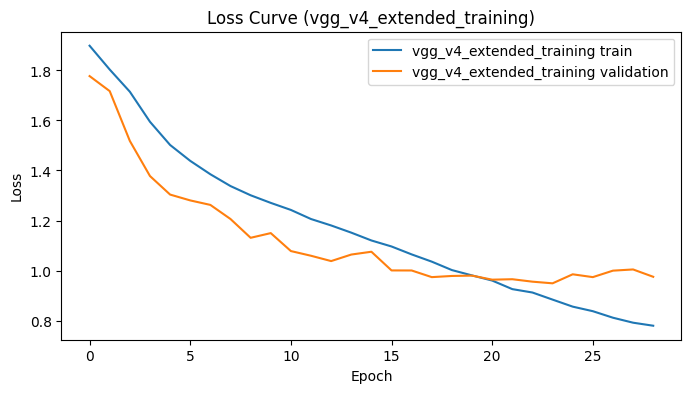

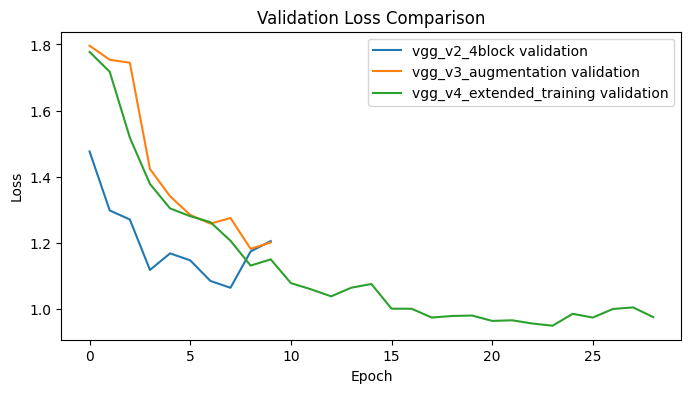

In [45]:
# Selected experiment curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label=f"{EXPERIMENT} train")
plt.plot(val_losses, label=f"{EXPERIMENT} validation")
plt.legend()
plt.title(f"Loss Curve ({EXPERIMENT})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Focused comparison controlled by COMPARE_EXPERIMENTS.
if len(comparison_histories) > 1:
    plt.figure(figsize=(8, 4))
    for experiment, experiment_history in comparison_histories.items():
        plt.plot(
            experiment_history["validation_loss"],
            label=f"{experiment} validation",
        )
    plt.legend()
    plt.title("Validation Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()


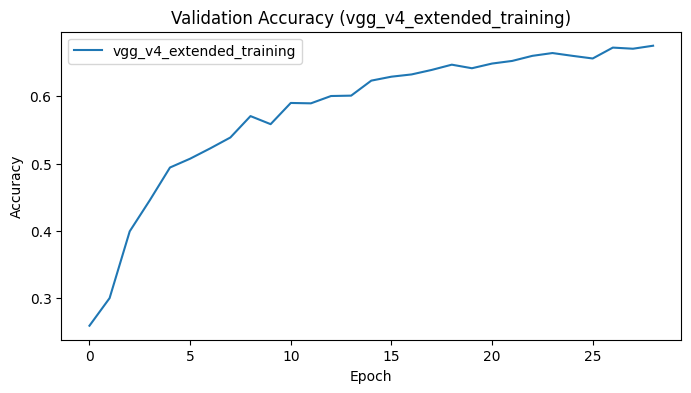

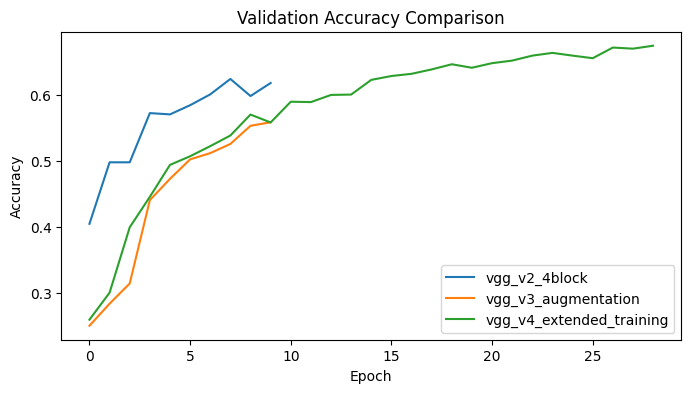

Best validation accuracy by experiment:
  vgg_v2_4block: 0.6247
  vgg_v3_augmentation: 0.5589
  vgg_v4_extended_training: 0.6751


In [46]:
plt.figure(figsize=(8, 4))
plt.plot(val_accuracies, label=EXPERIMENT)
plt.legend()
plt.title(f"Validation Accuracy ({EXPERIMENT})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

if len(comparison_histories) > 1:
    plt.figure(figsize=(8, 4))
    for experiment, experiment_history in comparison_histories.items():
        plt.plot(experiment_history["validation_accuracy"], label=experiment)
    plt.legend()
    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

    print("Best validation accuracy by experiment:")
    for experiment, experiment_history in comparison_histories.items():
        best = experiment_history["best_validation_accuracy"]
        print(f"  {experiment}: {best:.4f}")


In [47]:
best_validation_results = []
for experiment in list_experiments(ROOT):
    best_accuracy = load_history(experiment, ROOT).get("best_validation_accuracy")
    if best_accuracy is not None:
        best_validation_results.append((experiment, best_accuracy))

if best_validation_results:
    best_experiment, best_accuracy = max(
        best_validation_results,
        key=lambda result: result[1],
    )
    print(
        f"Best Val Accuracy Across All Experiments ({best_experiment}): "
        f"{best_accuracy:.4f}"
    )
else:
    print("No validation accuracy is available for any experiment.")

Best Val Accuracy Across All Experiments (vgg_v4_extended_training): 0.6751


### Observations:
- **vgg_v1_batchnorm:** Validation loss reached its minimum around epoch 5 and increased slightly afterward, while validation accuracy continued to improve and reached its highest value at the final epoch (~60.3%), suggesting that the model had not yet clearly converged within the 10-epoch training budget.

- **vgg_v2_4block:** The deeper 4-block model achieved a higher peak validation accuracy than V1, suggesting that the additional convolutional depth improved feature learning. Validation accuracy peaked at ~62.4% around epoch 7. After epoch 7, training loss continued to decrease while validation loss increased and validation accuracy declined from its peak. This indicates the beginning of overfitting and suggests that further improvements may require better generalization rather than simply increasing model depth or training duration.

- **vgg_v3_augmentation:** Data augmentation **did not** improve validation accuracy (~56%) within the fixed **10-epoch** training budget. However, V3 showed a substantially different learning pattern. Validation accuracy continued to trend upward through the final epochs, while validation loss generally continued to decrease.This suggests that the added augmentation made the training task more difficult and slowed convergence. Longer training is needed to determine whether V3 can continue improving and eventually match or exceed V2.

- **vgg_v4_extended_training:** Extended training **substantially improved** the performance of the augmented model. Validation accuracy (~67.5%) continued to increase well beyond the original 10-epoch training budget. This confirms that the lower performance observed in V3 was largely associated with slower convergence after introducing data augmentation. Validation loss reached its minimum around epoch 24 and then remained relatively stable with small fluctuations, while validation accuracy continued to improve and reached its highest observed value at epoch 29. This difference between the best-loss and best-accuracy epochs suggests that the checkpoint-selection criterion may be worth examining in a later experiment.

## 3. Model Analysis

### Predictions

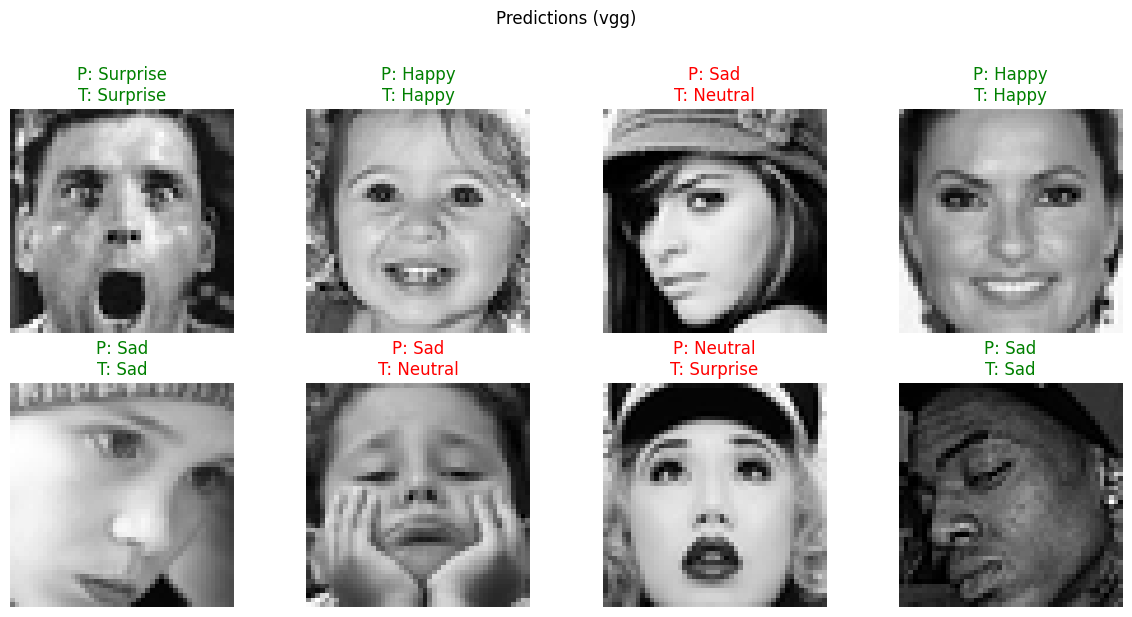

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import random
import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, get_device, load_trained_model

# Uses EXPERIMENT from the Training Summary setup cell.
val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")
device = get_device()
model = load_trained_model(EXPERIMENT, device, ROOT)

indices = random.sample(range(len(val_dataset)), 8)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")

    title = f"P: {FERDataset.class_names[pred]}\nT: {FERDataset.class_names[label]}"
    color = "green" if pred == label else "red"
    plt.title(title, color=color)

    plt.axis("off")

plt.suptitle(f"Predictions ({EXPERIMENT})", y=1.02)
plt.tight_layout()
plt.show()


### Confusion Matrix

[[197   7  62  42  93  14  52]
 [  7  23   6   6  11   0   3]
 [ 33   0 224  26 108  47  58]
 [ 18   0  29 716  50  19  63]
 [ 62   0 101  49 313  15 113]
 [ 13   0  35  22  17 312  16]
 [ 49   1  57  60 114  13 313]]


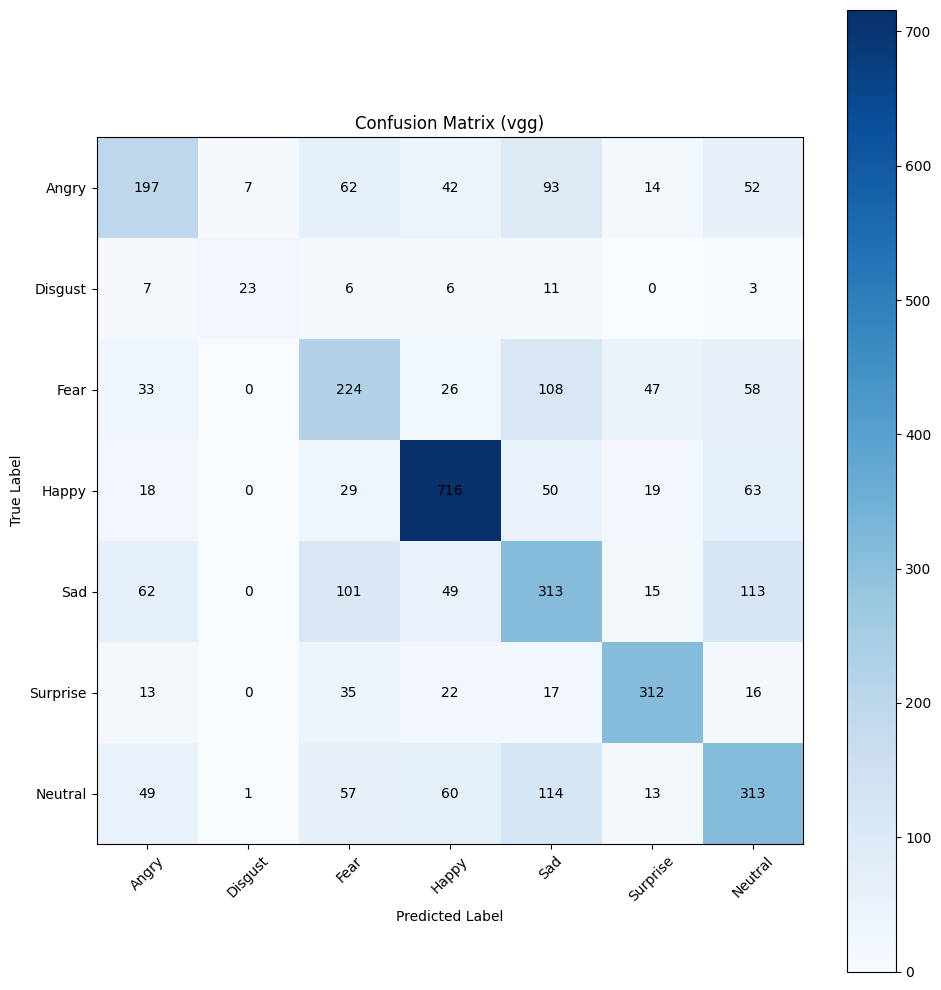

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

import sys
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, load_predictions

class_names = list(FERDataset.class_names)

y_true, y_pred = load_predictions(EXPERIMENT, ROOT)

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
print(cm)

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({EXPERIMENT})")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center")

plt.tight_layout()
plt.show()


#### Observations
- Happy has the strongest performance.
- Disjust has the least recognition.
- Negative emotions, such as anger, fear, and sadness, are often confused.

#### Confusion pair analysis

In [7]:
import sys
from pathlib import Path

import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, get_device, load_trained_model

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")
device = get_device()
model = load_trained_model(EXPERIMENT, device, ROOT)

target_true = 2   # Fear
target_pred = 5   # Surprise

pair_indices = []

for idx in range(len(val_dataset)):
    image, label = val_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    if label == target_true and pred == target_pred:
        pair_indices.append(idx)

print(
    f"Found {len(pair_indices)} "
    f"{FERDataset.class_names[target_true]}→"
    f"{FERDataset.class_names[target_pred]} pairs ({EXPERIMENT})"
)


Found 47 Fear→Surprise pairs (vgg)


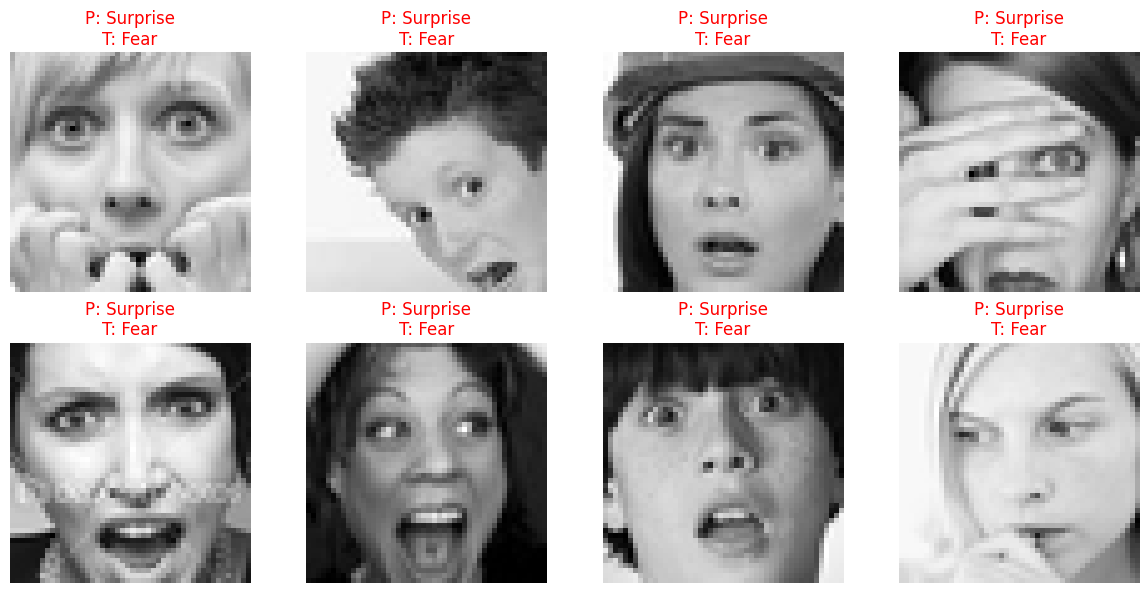

In [8]:
import matplotlib.pyplot as plt

sample_pair = pair_indices[:8]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_pair):
    image, label = val_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"P: {FERDataset.class_names[pred]}\nT: {FERDataset.class_names[label]}", color="red")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Grad-CAM Visualization

In [9]:
import sys
from pathlib import Path
import random
import matplotlib.pyplot as plt
import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))

from main import FERDataset, get_device, load_trained_model, get_gradcam_layer
from gradcam import GradCAM


Model output shape: (1, 7)
Saved activation shape: (1, 256, 12, 12)
Saved gradient shape: (1, 256, 12, 12)
Raw CAM shape: (12, 12)
Resized CAM shape: (48, 48)


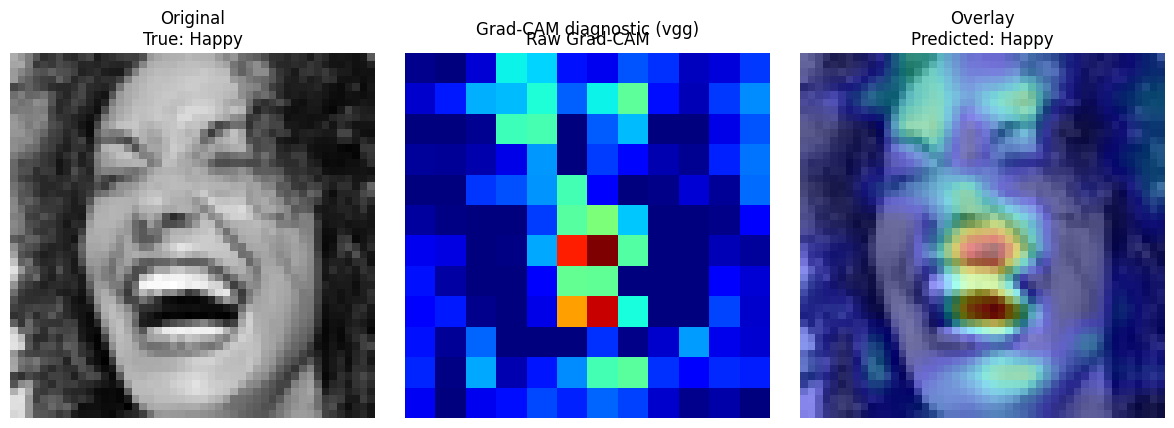

In [10]:
class_names = list(FERDataset.class_names)

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")
device = get_device()
model = load_trained_model(EXPERIMENT, device, ROOT)

# GradCAM remains architecture-agnostic; MODEL_NAME is resolved from config.
gradcam = GradCAM(model, get_gradcam_layer(model, MODEL_NAME))

idx = random.randrange(len(val_dataset))
image, label = val_dataset[idx]
input_tensor = image.unsqueeze(0).to(device)

try:
    # If class_idx is omitted, Grad-CAM explains the model's top prediction.
    raw_cam, pred = gradcam.generate(input_tensor)
    fig, axes, resized_cam = gradcam.visualize(
        image,
        raw_cam,
        alpha=0.4,
        print_diagnostics=True,
    )
    axes[0].set_title(f"Original\nTrue: {class_names[label]}")
    axes[2].set_title(f"Overlay\nPredicted: {class_names[pred]}")
    fig.suptitle(f"Grad-CAM diagnostic ({EXPERIMENT})", y=1.03)
    plt.show()
finally:
    gradcam.remove_hooks()
